# Black-Scholes Option Pricing

This noteobok prices European call options using two approaches:
- **Monte Carlo simulation** - simulate thousands of possible future stock prices and average the payoffs
- **Black-Scholes formula** - the exact analytical solution derived by Black and Scholes in 1973

Stock prices are modelled using Geometric Brownian Motion:

$$S_t = S_{t-1} \cdot e^{(r - \frac{1}{2}\sigma^2)\Delta t + 
\sigma\sqrt{\Delta t}\, Z_t}$$

where $Z_t$ is standard Gaussian noise, $r$ is the risk-free rate, and $\sigma$ is the volatility of the stock. 

A European call option gives the holder the right, but not the obligation, to buy a stock at a fixed strike price $K$ at expiry $T$. 
The payoff at expiry is:

$$\text{Payoff} = \max(S_T - K,\ 0)$$







In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

import os
os.makedirs('images', exist_ok=True)

def simulate_gbm(S0, r, sigma, T, N, num_paths):
    dt = T/N
    Z = np.random.normal(0,1,(num_paths,N))
    steps = np.exp((r-0.5*sigma**2)*dt + sigma * np.sqrt(dt) * Z)

    paths = np.ones((num_paths, N+1))*S0

    paths[:,1:] = S0* np.cumprod(steps, axis=1)
   
    return paths


def plot_paths(multiple_paths,T,num_to_plot):
    plt.figure()
    for i in range(num_to_plot):
        plt.plot(multiple_paths[i],alpha = 0.4)
    plt.xlabel('Time')
    plt.ylabel('Stock Price')
    plt.title('Simulated paths')
    plt.show()


def monte_carlo_price(paths,K,r,T):
    final_prices = paths[:,-1]
    option_price = np.mean(np.maximum(final_prices - K, 0))*np.exp(-r*T)

    return option_price

def black_scholes_price(S0, K, r, sigma, T):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    C = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

    return C

def compute_greeks(S0, K, r, sigma, T):
    h_delta = 1        # £1 nudge in stock price
    h_vega = 0.01      # 1% nudge in volatility
    h_theta = 1/252    # one trading day nudge in time

    Delta = (black_scholes_price(S0 + h_delta, K, r, sigma, T) - 
             black_scholes_price(S0 - h_delta, K, r, sigma, T)) / (2 * h_delta)
    
    Vega = (black_scholes_price(S0, K, r, sigma + h_vega, T) - 
            black_scholes_price(S0, K, r, sigma - h_vega, T)) / (2 * h_vega)
    
    Theta = (black_scholes_price(S0, K, r, sigma, T + h_theta) - 
             black_scholes_price(S0, K, r, sigma, T - h_theta)) / (2 * h_theta)
    
    return Delta, Vega, Theta


## 1. Simulating Stock Price Paths

We simulate 100,000 stock price paths over one year using Geometric Brownian Motion. Each path represents one possible future evolution of the stock price. 

Notice how the paths fan out over time- uncertainty grows with the square root of time, so the spread of possible prices widens as we look further into the future. 

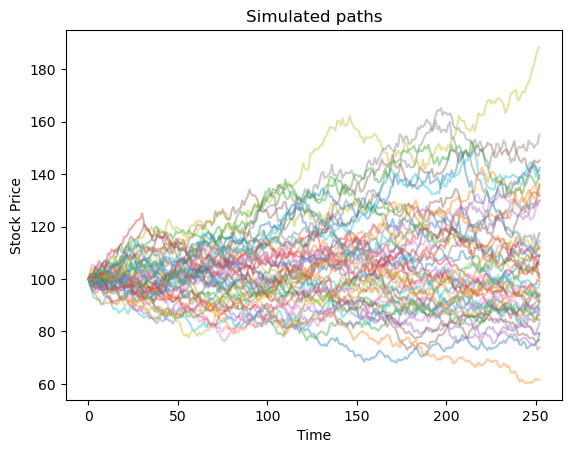

<Figure size 640x480 with 0 Axes>

In [2]:
paths = simulate_gbm(100,0.05,0.2,1,252,100000)
plot_paths(paths, 1, 50)
plt.savefig('images/stock_paths.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Monte Carlo Option Pricing

For each simulated path we record the final stock price $S_T$ and compute the payoff $\max(S_T - K, 0)$. The option price is the average payoff discounted back to today:

$$C \approx e^{-rT} \cdot \frac{1}{N}\sum_{i=1}^{N} \max(S_T^{(i)} - K,\ 0)$$

By the Law of Large Numbers, this average converges to the true option price as the number of simulated paths increases. The convergence plot below shows Monte Carlo homing in on the exact Black-Scholes value as we increase the number of paths. 

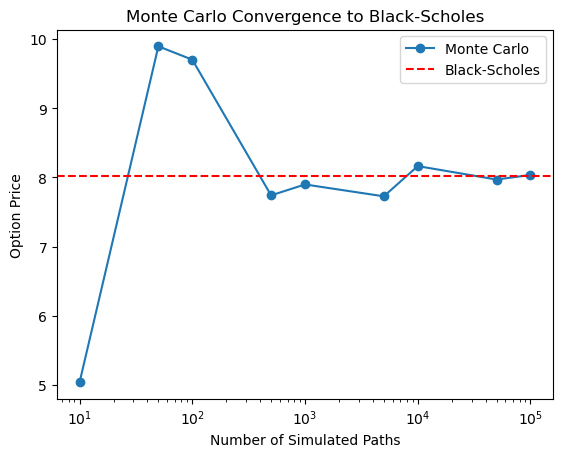

In [3]:

path_counts = [10,50,100,500,1000,5000,10000,50000,100000]
mc_prices = []

for n in path_counts:
    paths = simulate_gbm(100,0.05,0.2,1,252,n)
    price = monte_carlo_price(paths,105,0.05,1)
    mc_prices.append(price)

bs_price = black_scholes_price(100,105,0.05,0.2,1)

plt.figure()
plt.plot(path_counts, mc_prices, label = 'Monte Carlo', marker = 'o')
plt.axhline(bs_price, color = 'red', linestyle = '--', label = 'Black-Scholes')
plt.xscale('log')
plt.xlabel('Number of Simulated Paths')
plt.ylabel('Option Price')
plt.title('Monte Carlo Convergence to Black-Scholes')
plt.legend()
plt.savefig('images/convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. The Black-Scholes Formula

Black and Scholes derived an exact analytical formula for the option price in 1973, for which Scholes and Merton received the Nobel Prize:

$$C = S_0 \cdot N(d_1) - K e^{-rT} \cdot N(d_2)$$

$$d_1 = \frac{\ln(S_0/K) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, 
\qquad d_2 = d_1 - \sigma\sqrt{T}$$

where $N(\cdot)$ is the cumulative standard normal distribution. 

We verify our Monteo Carlo pricer against this formula across a range of parameter values. In each plot the two approaches agree closely, confirming the simulation is correct. 

**Price vs Volatility** - higher volatility means more uncertainty, which beenfits the option holder since payoffs are assymetric. The option price rises linearly with volatility. 

**Price vs Strike Price** - a higher strike means the stock must grow more before the option pays out. The price falls smoothly towards zero as $K$ increases. The dashes line marks the current stock price, seprataing in-the-money options (left) from the out-of-money (right). 

**Price vs Time to Expiry** - more time means more opportunity for a large favourable move. The price grows with $T$ but at a decreasing rate, reflecting the $\sqrt{T}$ scaling of uncertainty.


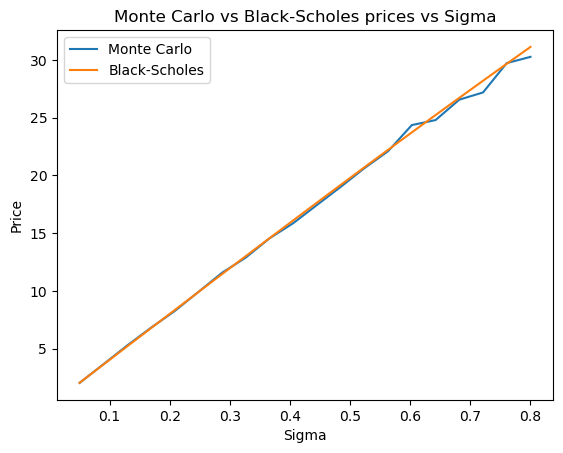

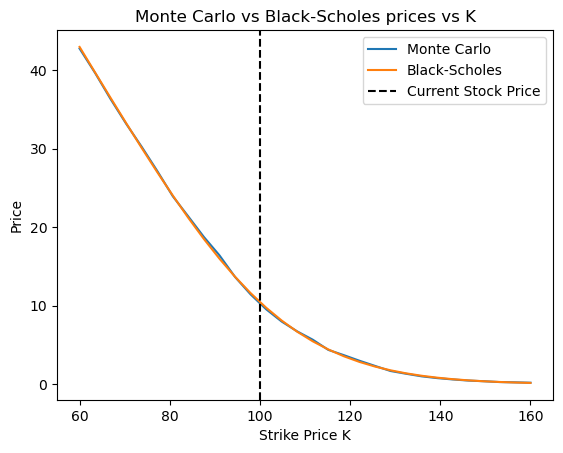

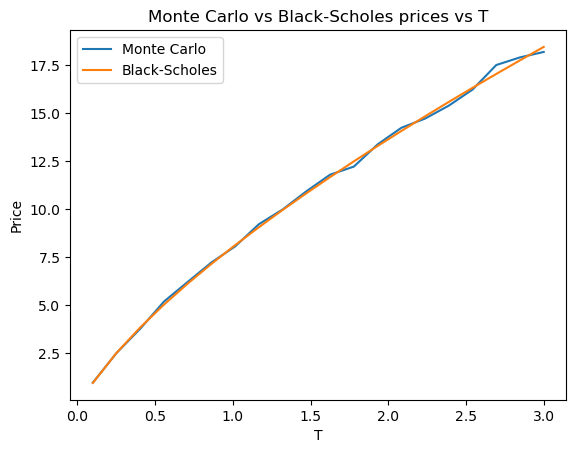

In [4]:
sigma_values = np.linspace(0.05,0.8,20)
mc_prices = []
bs_prices = []

for sigma in sigma_values:
    paths = paths = simulate_gbm(100,0.05,sigma,1,252,10000)
    price = monte_carlo_price(paths,105,0.05,1)
    mc_prices.append(price)
    bs_prices.append(black_scholes_price(100,105,0.05,sigma,1))

plt.figure()
plt.plot(sigma_values,mc_prices, label = 'Monte Carlo')
plt.plot(sigma_values,bs_prices, label = 'Black-Scholes')
plt.xlabel('Sigma')
plt.ylabel('Price')
plt.title('Monte Carlo vs Black-Scholes prices vs Sigma')
plt.legend()
plt.savefig('images/price_vs_sigma.png', dpi=150, bbox_inches='tight')
plt.show()

K_values = np.linspace(60,160,30)
mc_prices = []
bs_prices = []

for K in K_values:
    paths = paths = simulate_gbm(100,0.05,0.2,1,252,10000)
    price = monte_carlo_price(paths,K,0.05,1)
    mc_prices.append(price)
    bs_prices.append(black_scholes_price(100,K,0.05,0.2,1))

plt.figure()
plt.plot(K_values,mc_prices, label = 'Monte Carlo')
plt.plot(K_values,bs_prices, label = 'Black-Scholes')
plt.axvline(100,color = 'black', linestyle = '--', label = 'Current Stock Price')
plt.xlabel('Strike Price K')
plt.ylabel('Price')
plt.title('Monte Carlo vs Black-Scholes prices vs K')
plt.legend()
plt.savefig('images/price_vs_K.png', dpi=150, bbox_inches='tight')
plt.show()

T_values = np.linspace(0.1,3.0,20)
mc_prices = []
bs_prices = []

for T in T_values:
    paths = paths = simulate_gbm(100,0.05,0.2,T,252,10000)
    price = monte_carlo_price(paths,105,0.05,T)
    mc_prices.append(price)
    bs_prices.append(black_scholes_price(100,105,0.05,0.2,T))

plt.figure()
plt.plot(T_values,mc_prices, label = 'Monte Carlo')
plt.plot(T_values,bs_prices, label = 'Black-Scholes')
plt.xlabel('T')
plt.ylabel('Price')
plt.title('Monte Carlo vs Black-Scholes prices vs T')
plt.legend()
plt.savefig('images/price_vs_T.png', dpi=150, bbox_inches='tight')
plt.show()



## 4. The Greeks

The Greeks measure how sensitive the option price is to each input parameter. We compute them numerically using finite differences - nudging each parameter by a small amount and measuring the resulting change in price. 

- **Delta** - sensitivity to stock price. Ranges form 0 (deep out of the money) to 1 (deep in the money), forming an S-curve. Also approximates the probability that the option pays out at expiry.
- **Vega** - sensitivity to volatility. Peaks at the money, where uncertainty about the outcome is highest. Near zero when the outcomes is already fairly certian.
- **Theta** - sensitivity to time. Measures how much value the option loses as each day passes. Largest at the money, where time remaining has the most impact on the outcome.

Delta: 0.5422
Vega: 39.6704
Theta: 6.2771


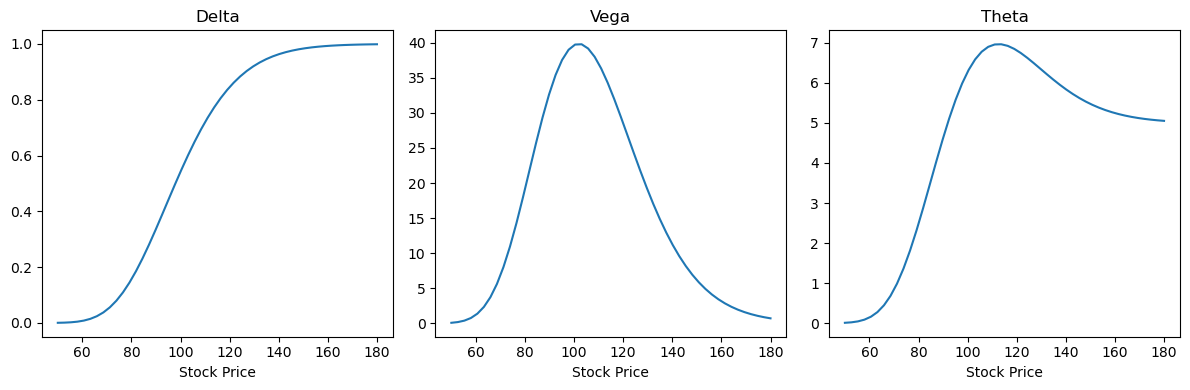

In [5]:
delta,vega,theta = compute_greeks(100,105,0.05,0.2,1)

print(f"Delta: {delta:.4f}")
print(f"Vega: {vega:.4f}")
print(f"Theta: {theta:.4f}")

S0_values = np.linspace(50,180,50)

greeks = []
for S0 in S0_values:
    greeks.append(compute_greeks(S0, 105, 0.05, 0.2, 1))

greeks = np.array(greeks)
deltas = greeks[:,0]
vegas = greeks[:,1]
thetas = greeks[:,2]


plt.figure(figsize = (12,4))

plt.subplot(1,3,1)
plt.plot(S0_values, deltas)
plt.title('Delta')
plt.xlabel('Stock Price')

plt.subplot(1,3,2)
plt.plot(S0_values, vegas)
plt.title('Vega')
plt.xlabel('Stock Price')

plt.subplot(1,3,3)
plt.plot(S0_values, thetas)
plt.title('Theta')
plt.xlabel('Stock Price')

plt.tight_layout()
plt.savefig('images/greeks.png', dpi=150, bbox_inches='tight')
plt.show()